# 1D periodic checkerboard

In [1]:
%reset -f
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.dataLib.synthetic import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader
from matplotlib import patches
import src.plot as custom_plot

Get samples from the 1D-Periodic checkerboard dataset

In [2]:
n_rows = 6
batch_size = 10000
dim = 1

checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=100000, dim = dim)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
# first_sample = batch[0]
print("sample shape of checkerboard dataset", batch.shape)

sample shape of checkerboard dataset torch.Size([10000, 1])


## Flat and embedded views

The one-dimensional flat torus is $T^1 = \mathbb{R}/\mathbb{Z}$, represented below by $[0,1)$ with $0 \equiv 1$. It is topologically a circle. The embedding

$$x \mapsto (\cos\theta, \sin\theta), \qquad \theta = 2\pi x,$$

maps the same periodic checkerboard onto $S^1 \subset \mathbb{R}^2$. Matching colors show how every flat tile becomes an arc of the circle.

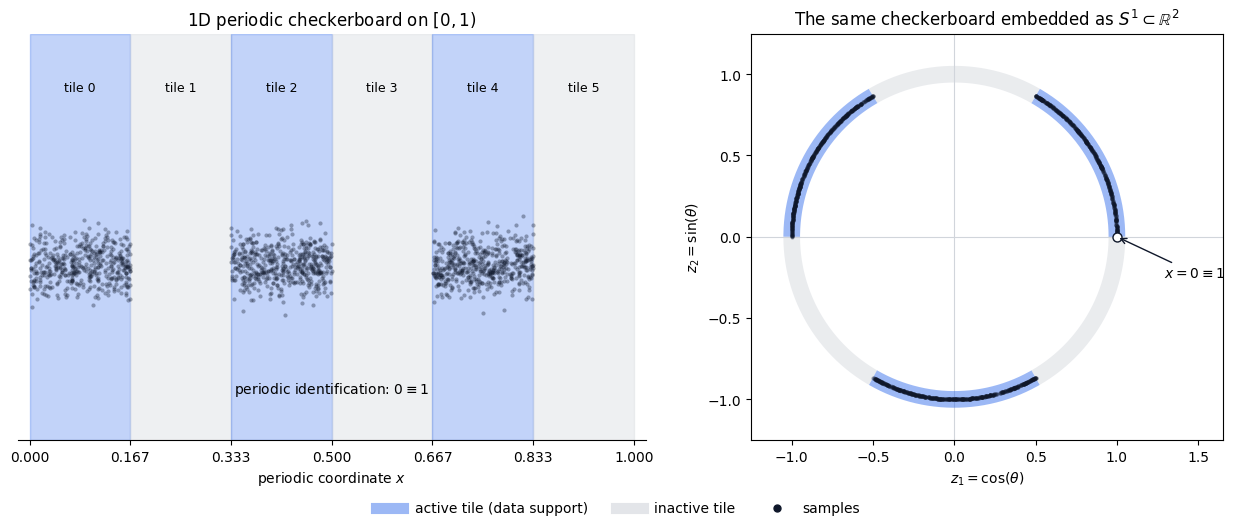

In [3]:
# Use the same tile colors in the flat and embedded views.
active_color = "#2563eb"
inactive_color = "#d1d5db"
sample_color = "#0f172a"

x_samples = batch[:, 0].detach().cpu().numpy()
rng = np.random.default_rng(0)
n_to_show = min(1500, len(x_samples))
shown = rng.choice(x_samples, size=n_to_show, replace=False)

fig, (ax_flat, ax_circle) = plt.subplots(
    1, 2, figsize=(13, 5.2), constrained_layout=True
)

# Flat representation: alternating tiles on [0, 1), with 0 and 1 identified.
tile_edges = np.linspace(0.0, 1.0, n_rows + 1)
for tile, (left, right) in enumerate(zip(tile_edges[:-1], tile_edges[1:])):
    is_active = tile % 2 == 0
    ax_flat.axvspan(
        left, right,
        color=active_color if is_active else inactive_color,
        alpha=0.28 if is_active else 0.35,
        zorder=0,
    )
    ax_flat.text(
        (left + right) / 2, 0.13,
        f"tile {tile}", ha="center", va="center", fontsize=9
    )

jitter = rng.normal(loc=0.0, scale=0.012, size=n_to_show)
ax_flat.scatter(shown, jitter, s=9, color=sample_color, alpha=0.35, linewidths=0)
ax_flat.text(0.5, -0.095, r"periodic identification: $0 \equiv 1$", ha="center")
ax_flat.set(
    xlim=(-0.02, 1.02), ylim=(-0.13, 0.17),
    xlabel=r"periodic coordinate $x$",
    title="1D periodic checkerboard on $[0,1)$",
)
ax_flat.set_xticks(tile_edges)
ax_flat.set_yticks([])
ax_flat.spines[["left", "right", "top"]].set_visible(False)

# S^1 embedding used by FlatTorus01.to_ambient(): theta = 2*pi*x.
for tile, (left, right) in enumerate(zip(tile_edges[:-1], tile_edges[1:])):
    theta_tile = np.linspace(
        2 * np.pi * left,
        2 * np.pi * right,
        200,
    )
    is_active = tile % 2 == 0
    ax_circle.plot(
        np.cos(theta_tile), np.sin(theta_tile),
        color=active_color if is_active else inactive_color,
        linewidth=12, alpha=0.45, solid_capstyle="butt", zorder=1,
    )

theta_samples = 2 * np.pi * shown
ax_circle.scatter(
    np.cos(theta_samples), np.sin(theta_samples),
    s=9, color=sample_color, alpha=0.35, linewidths=0, zorder=2,
)
ax_circle.scatter([1], [0], s=42, facecolor="white", edgecolor=sample_color, zorder=3)
ax_circle.annotate(
    r"$x=0 \equiv 1$", xy=(1, 0), xytext=(1.48, -0.25),
    arrowprops={"arrowstyle": "->", "color": sample_color},
    ha="center",
)
ax_circle.axhline(0, color=inactive_color, linewidth=0.8, zorder=0)
ax_circle.axvline(0, color=inactive_color, linewidth=0.8, zorder=0)
ax_circle.set(
    aspect="equal", xlim=(-1.25, 1.65), ylim=(-1.25, 1.25),
    xlabel=r"$z_1=\cos(\theta)$", ylabel=r"$z_2=\sin(\theta)$",
    title=r"The same checkerboard embedded as $S^1 \subset \mathbb{R}^2$",
)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=active_color, lw=8, alpha=0.45, label="active tile (data support)"),
    Line2D([0], [0], color=inactive_color, lw=8, alpha=0.6, label="inactive tile"),
    Line2D([0], [0], marker="o", linestyle="none", color=sample_color, markersize=5, label="samples"),
]
fig.legend(handles=legend_handles, loc="outside lower center", ncol=3, frameon=False)
plt.show()

## Intrinsic RG-VFM forward trajectories

For each checkerboard terminal state $x_T$, RG-VFM draws a uniform prior sample $x_0$ on $T^1$ and follows the shortest periodic geodesic

$$x_t = \operatorname{Exp}_{x_0}\!\left(t\,\operatorname{Log}_{x_0}(x_T)\right), \qquad t \in [0,1].$$

The left panel shows the wrapped coordinate in $[0,1)$; lines are deliberately split at the identified boundary. The right panel shows the same continuous paths on the circle.

In [16]:
from src.flow_matching.rg_vfm import RGVFM
from src.manifolds.flat_torus import FlatTorus01

torch.manual_seed(7)
manifold = FlatTorus01(dim=dim)
rgvfm = RGVFM(manifold=manifold, support="intrinsic", noise_scale=0.01)

n_trajectories = 24
n_steps = 100
x_T = batch[:n_trajectories].clone()            # checkerboard terminal states
x_0 = rgvfm.sample_prior(x_T)                   # uniform prior on T^1
trajectory, x_T_targets, time_grid = rgvfm.sample_forward(
    x_T,
    x_0,
    sample_trajectory=True,
    n_steps=n_steps,
    return_time=True,
)

print("trajectory shape (time, sample, coordinate):", tuple(trajectory.shape))
print("maximum x_T error:", manifold.distance(trajectory[-1], x_T).max().item())

trajectory shape (time, sample, coordinate): (101, 24, 1)
maximum x_T error: 0.02759683132171631


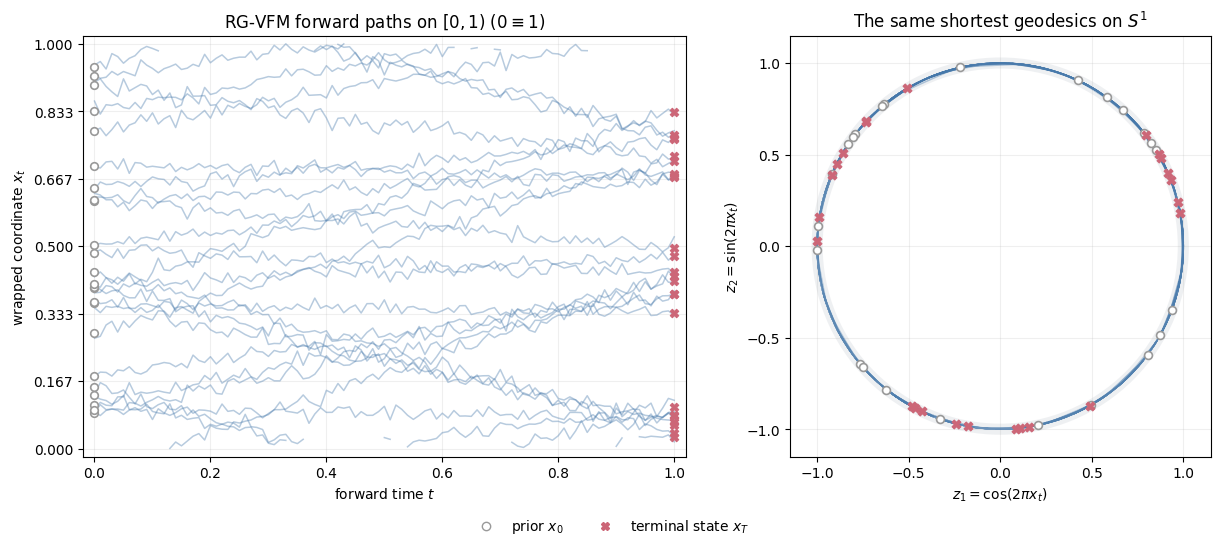

In [17]:
traj = trajectory.detach().cpu().numpy()[..., 0]
times = time_grid.detach().cpu().numpy()
x_0_np = x_0.detach().cpu().numpy()[:, 0]
x_T_np = x_T.detach().cpu().numpy()[:, 0]
# Muted, colorblind-friendly palette commonly used in academic figures.
flow_color = "#4477AA"
prior_color = "#999999"
data_color = "#CC6677"

fig, (ax_flat_path, ax_circle_path) = plt.subplots(
    1, 2, figsize=(13, 5.4), constrained_layout=True
)

for sample_idx in range(n_trajectories):
    # Break wrapped-coordinate lines at jumps across 0 == 1.
    wrapped_path = traj[:, sample_idx].copy()
    jump_after = np.flatnonzero(np.abs(np.diff(wrapped_path)) > 0.5) + 1
    wrapped_path[jump_after] = np.nan
    ax_flat_path.plot(times, wrapped_path, color=flow_color, lw=1.1, alpha=0.38)

    theta = 2 * np.pi * traj[:, sample_idx]
    ax_circle_path.plot(
        np.cos(theta), np.sin(theta), color=flow_color, lw=1.1, alpha=0.38
    )

ax_flat_path.scatter(
    np.zeros_like(x_0_np), x_0_np, marker="o", s=30,
    facecolors="white", edgecolors=prior_color, linewidths=1.2, zorder=3,
)
ax_flat_path.scatter(
    np.ones_like(x_T_np), x_T_np, marker="X", s=38,
    c=data_color, linewidths=0.7, zorder=3,
)
ax_flat_path.set(
    xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
    xlabel=r"forward time $t$", ylabel=r"wrapped coordinate $x_t$",
    title=r"RG-VFM forward paths on $[0,1)$ ($0 \equiv 1$)",
)
ax_flat_path.set_yticks(tile_edges)
ax_flat_path.grid(alpha=0.2)

theta_0 = 2 * np.pi * x_0_np
theta_T = 2 * np.pi * x_T_np
ax_circle_path.scatter(
    np.cos(theta_0), np.sin(theta_0), marker="o", s=32,
    facecolors="white", edgecolors=prior_color, linewidths=1.2, zorder=3,
)
ax_circle_path.scatter(
    np.cos(theta_T), np.sin(theta_T), marker="X", s=42,
    c=data_color, linewidths=0.7, zorder=3,
)
circle = plt.Circle((0, 0), 1, fill=False, color=inactive_color, lw=8, alpha=0.35)
ax_circle_path.add_patch(circle)
ax_circle_path.set(
    aspect="equal", xlim=(-1.15, 1.15), ylim=(-1.15, 1.15),
    xlabel=r"$z_1=\cos(2\pi x_t)$",
    ylabel=r"$z_2=\sin(2\pi x_t)$",
    title=r"The same shortest geodesics on $S^1$",
)
ax_circle_path.grid(alpha=0.2)

path_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white",
           markeredgecolor=prior_color, label=r"prior $x_0$"),
    Line2D([0], [0], marker="X", linestyle="none", color=data_color,
           label=r"terminal state $x_T$"),
]
fig.legend(handles=path_legend, loc="outside lower center", ncol=2, frameon=False)
plt.show()

## Intrinsic prior-to-data flow as two circles

Here the horizontal axis is time. The left circle contains prior samples at $t=0$, the right circle contains checkerboard data at $t=1$, and every curve is one RG-VFM forward flow trajectory.

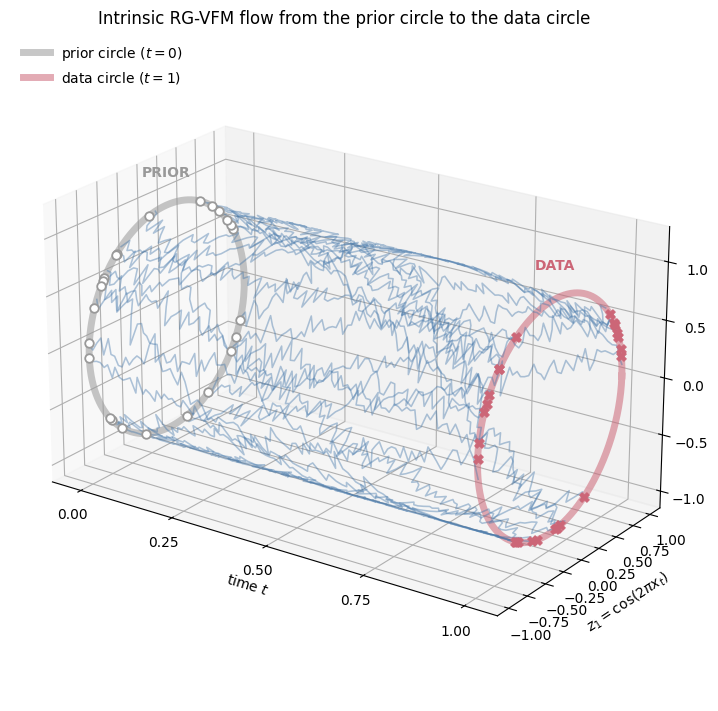

In [18]:
fig = plt.figure(figsize=(13, 7), constrained_layout=True)
ax_flow = fig.add_subplot(111, projection="3d")

circle_angle = np.linspace(0, 2 * np.pi, 400)
circle_y = np.cos(circle_angle)
circle_z = np.sin(circle_angle)

# The two boundary circles: prior at t=0 and data at t=1.
ax_flow.plot(
    np.zeros_like(circle_angle), circle_y, circle_z,
    color=prior_color, lw=5, alpha=0.55, label=r"prior circle ($t=0$)",
)
ax_flow.plot(
    np.ones_like(circle_angle), circle_y, circle_z,
    color=data_color, lw=5, alpha=0.55, label=r"data circle ($t=1$)",
)

# Lift x_t to S^1 and use time as the axis connecting the circles.
for sample_idx in range(n_trajectories):
    theta_path = 2 * np.pi * traj[:, sample_idx]
    ax_flow.plot(
        times, np.cos(theta_path), np.sin(theta_path),
        color=flow_color, lw=1.15, alpha=0.42,
    )

ax_flow.scatter(
    np.zeros_like(theta_0), np.cos(theta_0), np.sin(theta_0),
    marker="o", s=38, facecolors="white", edgecolors=prior_color,
    linewidths=1.3, depthshade=False, zorder=4,
)
ax_flow.scatter(
    np.ones_like(theta_T), np.cos(theta_T), np.sin(theta_T),
    marker="X", s=48, c=data_color, linewidths=0.7,
    depthshade=False, zorder=4,
)

ax_flow.text(0.0, 0.0, 1.25, "PRIOR", color=prior_color, ha="center", weight="bold")
ax_flow.text(1.0, 0.0, 1.25, "DATA", color=data_color, ha="center", weight="bold")
ax_flow.set(
    xlim=(-0.08, 1.08), ylim=(-1.15, 1.15), zlim=(-1.15, 1.3),
    xlabel=r"time $t$",
    ylabel=r"$z_1=\cos(2\pi x_t)$",
    zlabel=r"$z_2=\sin(2\pi x_t)$",
    title="Intrinsic RG-VFM flow from the prior circle to the data circle",
)
ax_flow.set_xticks(np.linspace(0, 1, 5))
ax_flow.set_box_aspect((1.8, 1, 1))
ax_flow.view_init(elev=22, azim=-55)
ax_flow.grid(alpha=0.2)
ax_flow.legend(loc="upper left", frameon=False)
plt.show()

## Extrinsic RG-VFM paths in the ambient space

For $T^1$, `FlatTorus01` declares `ambient_dim = 2`. In extrinsic mode, RG-VFM samples $x_0 \sim \mathcal{N}(0,I_2)$ directly in $\mathbb{R}^2$, embeds the terminal state as $\iota(x_T)=(\cos(2\pi x_T),\sin(2\pi x_T))$, and uses the Euclidean conditional path

$$z_t=(1-t)x_0+t\,\iota(x_T).$$

The intermediate states are not projected onto $S^1$; straight paths may pass through the inside or outside of the circle. Therefore this path is shown only in the ambient-space circle view, not in the flat intrinsic coordinate view.

In [19]:
torch.manual_seed(11)
rgvfm_extrinsic = RGVFM(
    manifold=manifold,
    support="extrinsic",
    ambient_prior_scale=1.0,
    noise_scale=0.0,
)

x_T_extrinsic = batch[:n_trajectories].clone()
x_0_extrinsic = rgvfm_extrinsic.sample_prior(x_T_extrinsic)
extrinsic_trajectory, extrinsic_x_T_targets, extrinsic_time_grid = (
    rgvfm_extrinsic.sample_forward(
        x_T_extrinsic,
        x_0_extrinsic,
        sample_trajectory=True,
        n_steps=n_steps,
        return_time=True,
    )
)

x_T_error = torch.linalg.vector_norm(
    extrinsic_trajectory[-1] - extrinsic_x_T_targets[-1], dim=-1
).max()
x_T_radius_error = (
    torch.linalg.vector_norm(extrinsic_x_T_targets[-1], dim=-1) - 1.0
).abs().max()
print("intrinsic_dim / ambient_dim:", manifold.intrinsic_dim, manifold.ambient_dim)
print("x_0 shape in ambient space:", tuple(x_0_extrinsic.shape))
print("trajectory shape (time, sample, ambient coordinate):", tuple(extrinsic_trajectory.shape))
print("maximum x_T error:", x_T_error.item())
print("maximum x_T radius error:", x_T_radius_error.item())

intrinsic_dim / ambient_dim: 1 2
x_0 shape in ambient space: (24, 2)
trajectory shape (time, sample, ambient coordinate): (101, 24, 2)
maximum x_T error: 1.2287812012345967e-07
maximum x_T radius error: 5.960464477539063e-08


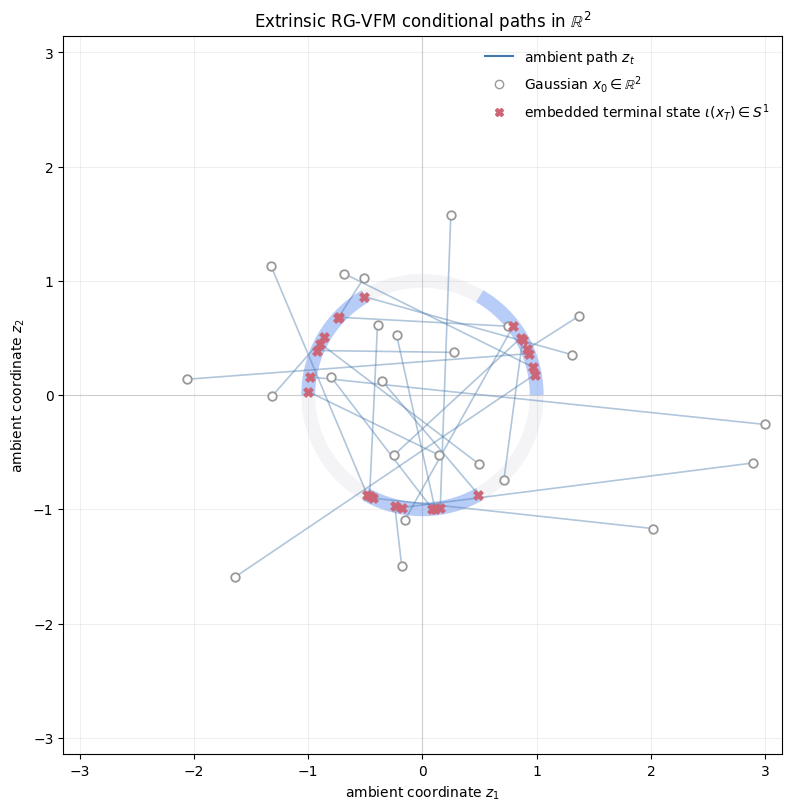

In [20]:
extrinsic_path_np = extrinsic_trajectory.detach().cpu().numpy()
extrinsic_x_0_np = x_0_extrinsic.detach().cpu().numpy()
extrinsic_x_T_np = extrinsic_x_T_targets[-1].detach().cpu().numpy()

fig, ax_ambient_path = plt.subplots(figsize=(8, 8), constrained_layout=True)

# Draw the embedded checkerboard support using the manifold's theta = 2*pi*x convention.
for tile, (left, right) in enumerate(zip(tile_edges[:-1], tile_edges[1:])):
    theta_tile = np.linspace(2 * np.pi * left, 2 * np.pi * right, 200)
    is_active = tile % 2 == 0
    ax_ambient_path.plot(
        np.cos(theta_tile),
        np.sin(theta_tile),
        color=active_color if is_active else inactive_color,
        lw=10,
        alpha=0.32 if is_active else 0.24,
        solid_capstyle="butt",
        zorder=0,
    )

# Plot z_t directly in R^2. Do not apply atan2, to_intrinsic, or project_ambient.
for sample_idx in range(n_trajectories):
    ax_ambient_path.plot(
        extrinsic_path_np[:, sample_idx, 0],
        extrinsic_path_np[:, sample_idx, 1],
        color=flow_color,
        lw=1.2,
        alpha=0.42,
        zorder=1,
    )

ax_ambient_path.scatter(
    extrinsic_x_0_np[:, 0], extrinsic_x_0_np[:, 1],
    marker="o", s=38, facecolors="white", edgecolors=prior_color,
    linewidths=1.3, zorder=3,
)
ax_ambient_path.scatter(
    extrinsic_x_T_np[:, 0], extrinsic_x_T_np[:, 1],
    marker="X", s=48, c=data_color, linewidths=0.7, zorder=4,
)

plot_limit = max(1.25, float(np.abs(extrinsic_path_np).max()) + 0.15)
ax_ambient_path.axhline(0, color=inactive_color, lw=0.8, zorder=-1)
ax_ambient_path.axvline(0, color=inactive_color, lw=0.8, zorder=-1)
ax_ambient_path.set(
    aspect="equal",
    xlim=(-plot_limit, plot_limit),
    ylim=(-plot_limit, plot_limit),
    xlabel=r"ambient coordinate $z_1$",
    ylabel=r"ambient coordinate $z_2$",
    title=r"Extrinsic RG-VFM conditional paths in $\mathbb{R}^2$",
)
ax_ambient_path.grid(alpha=0.2)
ambient_legend = [
    Line2D([0], [0], color=flow_color, lw=1.5, label=r"ambient path $z_t$"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white",
           markeredgecolor=prior_color, label=r"Gaussian $x_0 \in \mathbb{R}^2$"),
    Line2D([0], [0], marker="X", linestyle="none", color=data_color,
           label=r"embedded terminal state $\iota(x_T) \in S^1$"),
]
ax_ambient_path.legend(handles=ambient_legend, loc="upper right", frameon=False)
plt.show()

## Extrinsic trajectories across time

This three-dimensional view uses $(t,z_1,z_2)$, where $(z_1,z_2)=(\cos\theta,\sin\theta)$ only when a state lies on the embedded circle. The circles at $t=0$ and $t=1$ are copies of the manifold used as visual references. Because the extrinsic prior is Gaussian in $\mathbb{R}^2$, $x_0$ is not constrained to the left circle; the terminal state $x_T$ does lie on the right circle. Intermediate paths are plotted directly in ambient coordinates without projection.

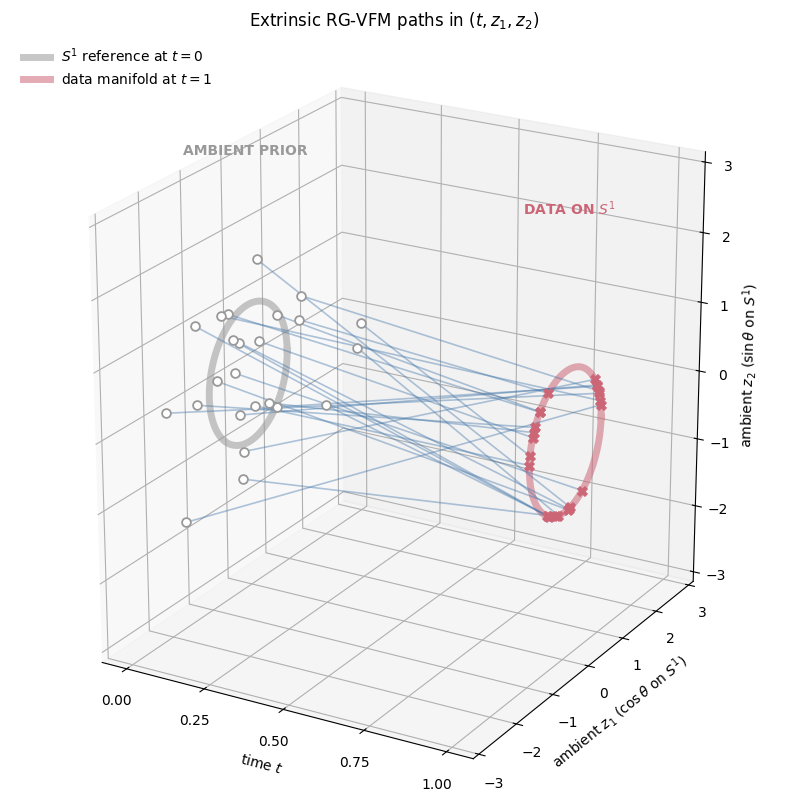

In [21]:
extrinsic_times_np = extrinsic_time_grid.detach().cpu().numpy()

fig = plt.figure(figsize=(13, 8), constrained_layout=True)
ax_extrinsic_flow = fig.add_subplot(111, projection="3d")

circle_angle = np.linspace(0, 2 * np.pi, 400)
circle_z1 = np.cos(circle_angle)
circle_z2 = np.sin(circle_angle)

# Two copies of the embedded manifold at the beginning and end of time.
ax_extrinsic_flow.plot(
    np.zeros_like(circle_angle), circle_z1, circle_z2,
    color=prior_color, lw=5, alpha=0.55,
    label=r"$S^1$ reference at $t=0$",
)
ax_extrinsic_flow.plot(
    np.ones_like(circle_angle), circle_z1, circle_z2,
    color=data_color, lw=5, alpha=0.55,
    label=r"data manifold at $t=1$",
)

# Use the ambient trajectory directly: (t, z_1(t), z_2(t)).
for sample_idx in range(n_trajectories):
    ax_extrinsic_flow.plot(
        extrinsic_times_np,
        extrinsic_path_np[:, sample_idx, 0],
        extrinsic_path_np[:, sample_idx, 1],
        color=flow_color, lw=1.2, alpha=0.42,
    )

ax_extrinsic_flow.scatter(
    np.zeros(n_trajectories),
    extrinsic_x_0_np[:, 0],
    extrinsic_x_0_np[:, 1],
    marker="o", s=40, facecolors="white", edgecolors=prior_color,
    linewidths=1.3, depthshade=False, zorder=4,
)
ax_extrinsic_flow.scatter(
    np.ones(n_trajectories),
    extrinsic_x_T_np[:, 0],
    extrinsic_x_T_np[:, 1],
    marker="X", s=50, c=data_color, linewidths=0.7,
    depthshade=False, zorder=4,
)

ax_extrinsic_flow.text(
    0.0, 0.0, plot_limit, "AMBIENT PRIOR",
    color=prior_color, ha="center", weight="bold",
)
ax_extrinsic_flow.text(
    1.0, 0.0, plot_limit, "DATA ON $S^1$",
    color=data_color, ha="center", weight="bold",
)
ax_extrinsic_flow.set(
    xlim=(-0.08, 1.08),
    ylim=(-plot_limit, plot_limit),
    zlim=(-plot_limit, plot_limit),
    xlabel=r"time $t$",
    ylabel=r"ambient $z_1$ ($\cos\theta$ on $S^1$)",
    zlabel=r"ambient $z_2$ ($\sin\theta$ on $S^1$)",
    title=r"Extrinsic RG-VFM paths in $(t,z_1,z_2)$",
)
ax_extrinsic_flow.set_xticks(np.linspace(0, 1, 5))
ax_extrinsic_flow.set_box_aspect((1.8, 2, 2))
ax_extrinsic_flow.view_init(elev=22, azim=-60)
ax_extrinsic_flow.grid(alpha=0.2)
ax_extrinsic_flow.legend(loc="upper left", frameon=False)
plt.show()